In [1]:
import time
import copy
import torch
from torch import optim, nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.models import resnet18
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import sys
sys.path.append("..")
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore") # 忽略警告

In [2]:
def read_images(root="E:\\毕设\\训练数据\\voc2012\\VOCdevkit\\VOC2012", is_train=True, max_num = None):
    """
    读取训练图像，并且以RGB的格式存储
    :param root: 根路径
    :param is_train: 是否是训练模式（也就是是读取训练数据还是验证数据）
    :param max_num: 最大数量
    :return:
    """
    txt_file_name = f'{root}/ImageSets/Segmentation/{"train.txt" if is_train else "val.txt"}'
    with open(txt_file_name, 'r') as f:
        images = f.read().split()           # 将文件名以list形式读取

    # 如果指定了最大读取大小
    if max_num is not None:
        images = images[:min(max_num, len(images))]

    features, labels = [None] * len(images), [None] * len(images)
    for index, file_name in tqdm(enumerate(images), total=len(images)):
        # 读入数据，并且全部转为RGB形式的PIL的image
        features[index] = Image.open(f'{root}/JPEGImages/{file_name}.jpg').convert('RGB')
        labels[index] = Image.open(f'{root}/SegmentationClass/{file_name}.png').convert('RGB')

    return features, labels

In [3]:
# 这个函数可以不需要
def set_figsize(figsize=(3.5, 2.5)):
    """在jupyter使用svg显示"""
    display.set_matplotlib_formats('svg')
    # 设置图的尺寸
    plt.rcParams['figure.figsize'] = figsize

def show_images(imgs, num_rows, num_cols, scale=2):
    # a_img = np.asarray(imgs)
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    for i in range(num_rows):
        for j in range(num_cols):
            axes[i][j].imshow(imgs[i * num_cols + j])
            axes[i][j].axes.get_xaxis().set_visible(False)
            axes[i][j].axes.get_yaxis().set_visible(False)
    plt.show()
    return axes

100%|██████████| 10/10 [00:00<00:00, 544.11it/s]


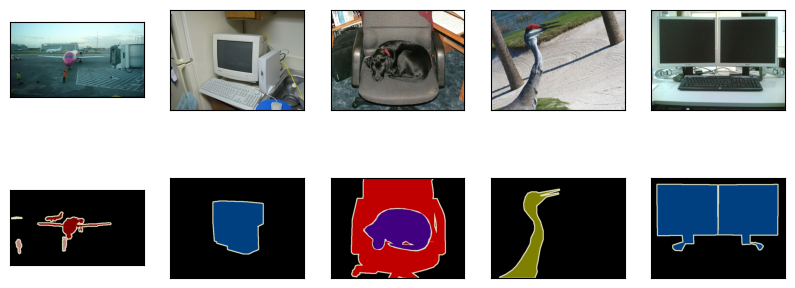

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [4]:
# 根据自己存放数据集的路径修改voc_dir
voc_dir = 'E:\\毕设\\训练数据\\voc2012\\VOCdevkit\\VOC2012'
train_features, train_labels = read_images(voc_dir, max_num=10)
n = 5 # 展示几张图像
imgs = train_features[0:n] + train_labels[0:n] # PIL image
show_images(imgs, 2, n)

In [5]:
# 标签中每个RGB颜色的值
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]
# 标签其标注的类别
VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']


In [6]:
colormap2label = torch.zeros(256**3, dtype=torch.uint8) # torch.Size([16777216])
for i, colormap in enumerate(VOC_COLORMAP):
    # 每个通道的进制是256，这样可以保证每个 rgb 对应一个下标 i
    colormap2label[(colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i

# 构造标签矩阵
def label_indices(colormap, colormap2label):
    colormap = np.array(colormap.convert("RGB")).astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256 + colormap[:, :, 2])
    return colormap2label[idx] # colormap 映射 到colormaplabel中计算的下标

In [7]:
y = label_indices(train_labels[0], colormap2label)
print(y[100:110, 130:140]) #打印结果是一个int型tensor，tensor中的每个元素i表示该像素的类别是VOC_CLASSES[i]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]], dtype=torch.uint8)


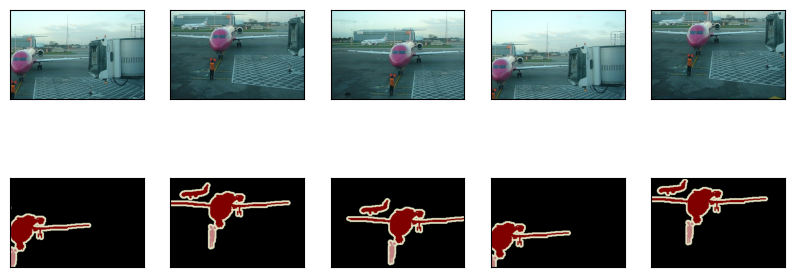

In [8]:
def rand_crop(feature, label, height, width):
    """
    随机裁剪feature(PIL image) 和 label(PIL image).
    为了使裁剪的区域相同，不能直接使用RandomCrop，而要像下面这样做
    Get parameters for ``crop`` for a random crop.
    Args:
        img (PIL Image): Image to be cropped.
        output_size (tuple): Expected output size of the crop.
    Returns:
        tuple: params (i, j, h, w) to be passed to ``crop`` for random crop.
    """
    i,j,h,w = torchvision.transforms.RandomCrop.get_params(feature, output_size=(height, width))
    feature = torchvision.transforms.functional.crop(feature, i, j, h, w)
    label = torchvision.transforms.functional.crop(label, i, j, h, w)
    return feature, label

# 显示n张随机裁剪的图像和标签，前面的n是5
imgs = []
for _ in range(n):
    imgs += rand_crop(train_features[0], train_labels[0], 200, 300)
show_images(imgs[::2] + imgs[1::2], 2, n);


In [9]:
class VOCSegDataset(torch.utils.data.Dataset):
    def __init__(self, is_train, crop_size, voc_dir, colormap2label, max_num=None):
        """
        crop_size: (h, w)
        """
        # 对输入图像的RGB三个通道的值分别做标准化
        self.rgb_mean = np.array([0.485, 0.456, 0.406])
        self.rgb_std = np.array([0.229, 0.224, 0.225])
        self.tsf = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean=self.rgb_mean, std=self.rgb_std)])
        self.crop_size = crop_size # (h, w)
        features, labels = read_images(root=voc_dir, is_train=is_train,  max_num=max_num)
# 由于数据集中有些图像的尺寸可能小于随机裁剪所指定的输出尺寸，这些样本需要通过自定义的filter函数所移除
        self.features = self.filter(features) # PIL image
        self.labels = self.filter(labels)     # PIL image
        self.colormap2label = colormap2label
        print('read ' + str(len(self.features)) + ' valid examples')

    def filter(self, imgs):
        return [img for img in imgs if (
            img.size[1] >= self.crop_size[0] and img.size[0] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = rand_crop(self.features[idx], self.labels[idx], *self.crop_size)
                                # float32 tensor           uint8 tensor (b,h,w)
        return (self.tsf(feature), label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)


In [10]:
batch_size = 32 # 实际上我的小笔记本不允许我这么做！哭了（大家根据自己电脑内存改吧）
crop_size = (320, 480) # 指定随机裁剪的输出图像的形状为(320,480)
max_num = 20000 # 最多从本地读多少张图片，我指定的这个尺寸过滤完不合适的图像之后也就只有1175张~

# 创建训练集和测试集的实例
voc_train = VOCSegDataset(True, crop_size, voc_dir, colormap2label, max_num)
voc_test = VOCSegDataset(False, crop_size, voc_dir, colormap2label, max_num)

# 设批量大小为32，分别定义【训练集】和【测试集】的数据迭代器
num_workers = 0 if sys.platform.startswith('win32') else 4
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                              drop_last=True, num_workers=num_workers)
test_iter = torch.utils.data.DataLoader(voc_test, batch_size, drop_last=True,
                             num_workers=num_workers)

# 方便封装，把训练集和验证集保存在dict里
dataloaders = {'train':train_iter, 'val':test_iter}
dataset_sizes = {'train':len(voc_train), 'val':len(voc_test)}


100%|██████████| 1464/1464 [00:02<00:00, 507.45it/s]


read 1114 valid examples


100%|██████████| 1449/1449 [00:02<00:00, 508.84it/s]

read 1078 valid examples


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = 21 # 21分类，1个背景，20个物体
model_ft = resnet18(pretrained=True) # 设置True，表明要加载使用训练好的参数

# 特征提取器
for param in model_ft.parameters():
    param.requires_grad = False


In [12]:
model_ft = nn.Sequential(*list(model_ft.children())[:-2], # 去掉最后两层
              nn.Conv2d(512,num_classes,kernel_size=1), # 用大小为1的卷积层改变输出通道为num_class
              nn.ConvTranspose2d(num_classes,num_classes, kernel_size=64, padding=16, stride=32)).to(device) # 转置卷积层使图像变为输入图像的大小

In [13]:
# 双线性插值的上采样，用来初始化转置卷积层的卷积核
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size+1)//2
    if kernel_size%2 == 1:
        center = factor-1
    else:
        center = factor-0.5
    og = np.ogrid[:kernel_size, :kernel_size]
    filt = (1-abs(og[0]-center)/factor) * (1-abs(og[1]-center)/factor)
    weight = np.zeros((in_channels,out_channels, kernel_size,kernel_size), dtype='float32')
    weight[range(in_channels), range(out_channels), :, :] = filt
    weight = torch.Tensor(weight)
    weight.requires_grad = True
    return weight


In [14]:
nn.init.xavier_normal_(model_ft[-2].weight.data, gain=1)
model_ft[-1].weight.data = bilinear_kernel(num_classes, num_classes, 64).to(device)


In [15]:
def train_model(model:nn.Module, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    # 每个epoch都有一个训练和验证阶段
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-'*10)
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                model.train()
            else:
                model.eval()
            runing_loss = 0.0
            runing_corrects = 0.0
            # 迭代一个epoch
            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad() # 零参数梯度
				# 前向，只在训练时跟踪参数
                with torch.set_grad_enabled(phase=='train'):
                    logits = model(inputs)  # [5, 21, 320, 480]
                    loss = criteon(logits, labels.long())
                    # 后向，只在训练阶段进行优化
                    if phase=='train':
                        loss.backward()
                        optimizer.step()
				# 统计loss和correct
                runing_loss += loss.item()*inputs.size(0)
                runing_corrects += torch.sum((torch.argmax(logits.data,1))==labels.data)/(480*320)

            epoch_loss = runing_loss / dataset_sizes[phase]
            epoch_acc = runing_corrects.double() / dataset_sizes[phase]
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))
			# 深度复制model参数
            if phase=='val' and epoch_acc>best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()
    time_elapsed = time.time() - since;
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
    # 加载最佳模型权重
    model.load_state_dict(best_model_wts)
    return model
epochs = 5 # 训练5个epoch
criteon = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_ft.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9)
# 每3个epochs衰减LR通过设置gamma=0.1
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# 开始训练
model_ft = train_model(model_ft, criteon, optimizer, exp_lr_scheduler, num_epochs=epochs)


Epoch 0/4
----------
train Loss: 2.6679 Acc: 0.5404
val Loss: 1.9099 Acc: 0.6369

Epoch 1/4
----------
train Loss: 1.7110 Acc: 0.6663
val Loss: 1.5295 Acc: 0.6880

Epoch 2/4
----------
train Loss: 1.5102 Acc: 0.6872
val Loss: 1.4812 Acc: 0.6848

Epoch 3/4
----------
train Loss: 1.4783 Acc: 0.6837
val Loss: 1.4648 Acc: 0.6888

Epoch 4/4
----------
train Loss: 1.4601 Acc: 0.6837
val Loss: 1.4437 Acc: 0.6873

Training complete in 4m 60s


In [16]:
def label2image(pred):
    # pred: [320,480]
    colormap = torch.tensor(VOC_COLORMAP,device=device,dtype=int)
    x = pred.long()
    return (colormap[x,:]).data.cpu().numpy()


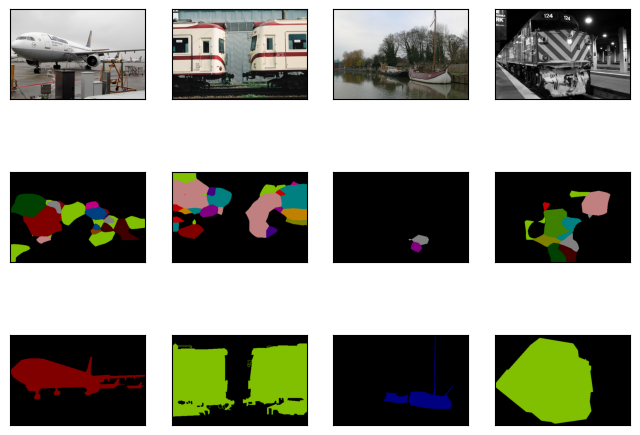

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [17]:
mean=torch.tensor([0.485, 0.456, 0.406]).reshape(3,1,1).to(device)
std=torch.tensor([0.229, 0.224, 0.225]).reshape(3,1,1).to(device)
def visualize_model(model:nn.Module, num_images=4):
    was_training = model.training
    model.eval()
    images_so_far = 0
    n, imgs = num_images, []
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs, labels = inputs.to(device), labels.to(device) # [b,3,320,480]
            outputs = model(inputs)
            pred = torch.argmax(outputs, dim=1) # [b,320,480]
            inputs_nd = (inputs*std+mean).permute(0,2,3,1)*255 # 记得要变回去哦

            for j in range(num_images):
                images_so_far += 1
                pred1 = label2image(pred[j]) # numpy.ndarray (320, 480, 3)
                imgs += [inputs_nd[j].data.int().cpu().numpy(), pred1, label2image(labels[j])]
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    # 我已经固定了每次只显示4张图了，大家可以自己修改
                    show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n)
                    return model.train(mode=was_training)

# 开始验证
visualize_model(model_ft)


100%|██████████| 10/10 [00:00<00:00, 620.39it/s]


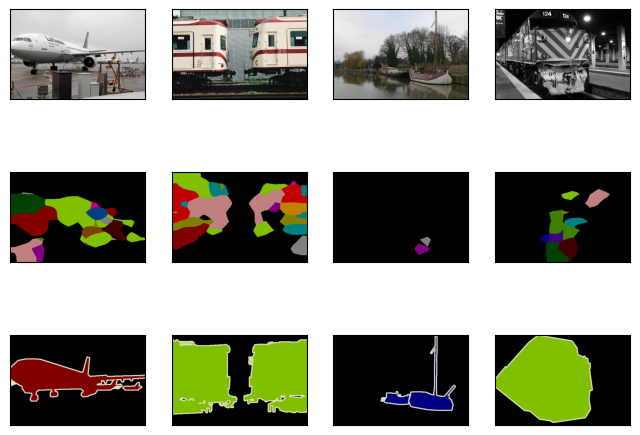

In [19]:
# 预测前将图像标准化，并转换成(b,c,h,w)的tensor
def predict(img, model):
    tsf = transforms.Compose([
            transforms.ToTensor(), # 好像会自动转换channel
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    x = tsf(img).unsqueeze(0).to(device) # (3,320,480) -> (1,3,320,480)
    pred = torch.argmax(model(x), dim=1) # 每个通道选择概率最大的那个像素点 -> (1,320,480)
    return pred.reshape(pred.shape[1],pred.shape[2]) # reshape成(320,480)

def evaluate(model:nn.Module):
    model.eval()
    test_images, test_labels = read_images(voc_dir, is_train=False, max_num=10)
    n, imgs = 4, []
    for i in range(n):
        xi, yi = rand_crop(test_images[i], test_labels[i], 320, 480) # Image
        pred = label2image(predict(xi, model))
        imgs += [xi, pred, yi]
    show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n)

# 开始测试
evaluate(model_ft)
